# 다중 실험 결과 비교 시각화

이 노트북은 experiment_date만 입력하면 해당 날짜의 모든 `*_learning.json` 파일들을 자동으로 로드해서 비교 시각화하는 기능을 제공합니다.

In [1]:
import os

os.chdir("/home/youngjins/project/belief_trading/")

import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import glob

# 스타일 설정
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")
plt.rcParams["font.size"] = 14
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 12

Loading experimental results by Beta...
Loaded 9 experimental results in total.
Analysis of Seller's True Preference Inference Performance by Beta

Total number of experiments: 9
Beta range: 1.5 ~ 3.0
Level combinations: L0B vs L1S, L1B vs L1S, L1B vs L2S

[Analysis based on Final Loss]
        mean     std     min     max  count
beta                                       
1.5   0.2635  0.3140  0.0522  0.6244      3
2.0   0.3713  0.2402  0.0948  0.5292      3
3.0   0.0697  0.0177  0.0508  0.0859      3

Best performing Beta: 3.0 (Average Final Loss: 0.0697)
Worst performing Beta: 2.0 (Average Final Loss: 0.3713)

[Analysis based on Best Loss]
        mean     std     min     max
beta                                
1.5   0.0842  0.0405  0.0522  0.1298
2.0   0.1924  0.1055  0.0888  0.2997
3.0   0.0620  0.0105  0.0503  0.0706

[Performance by Level Combination]
                     mean     std  count
level_combination                       
L0B vs L1S         0.3883  0.3000      3
L1B v

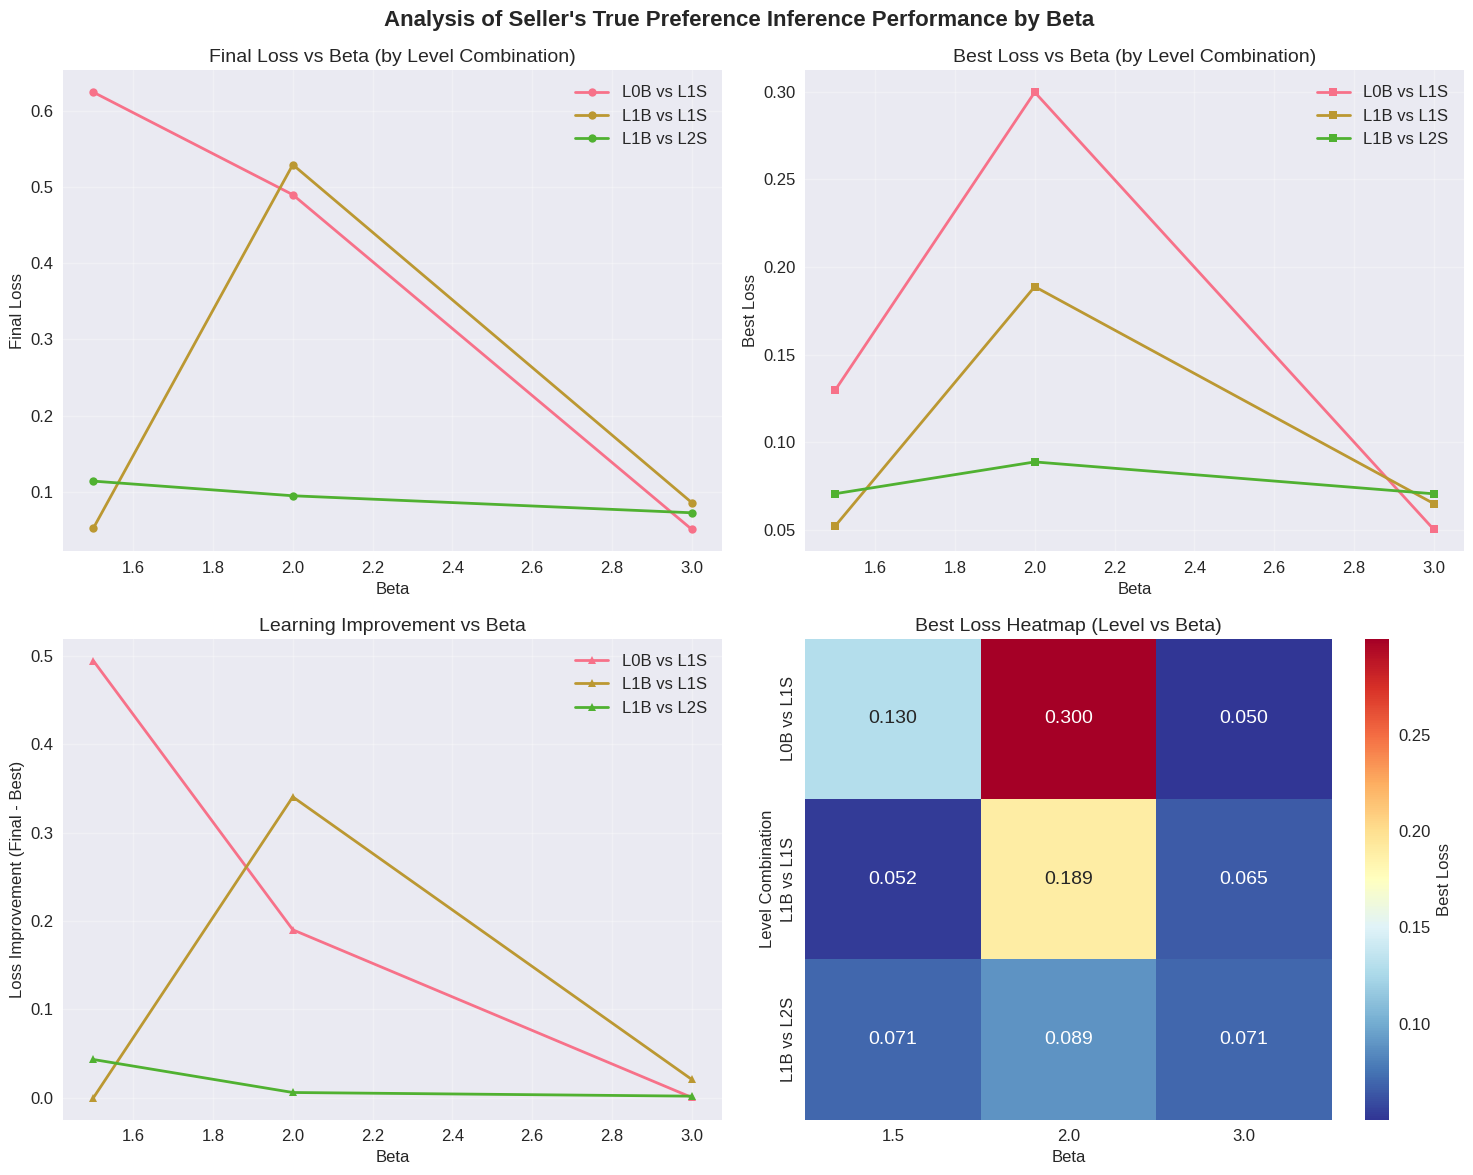

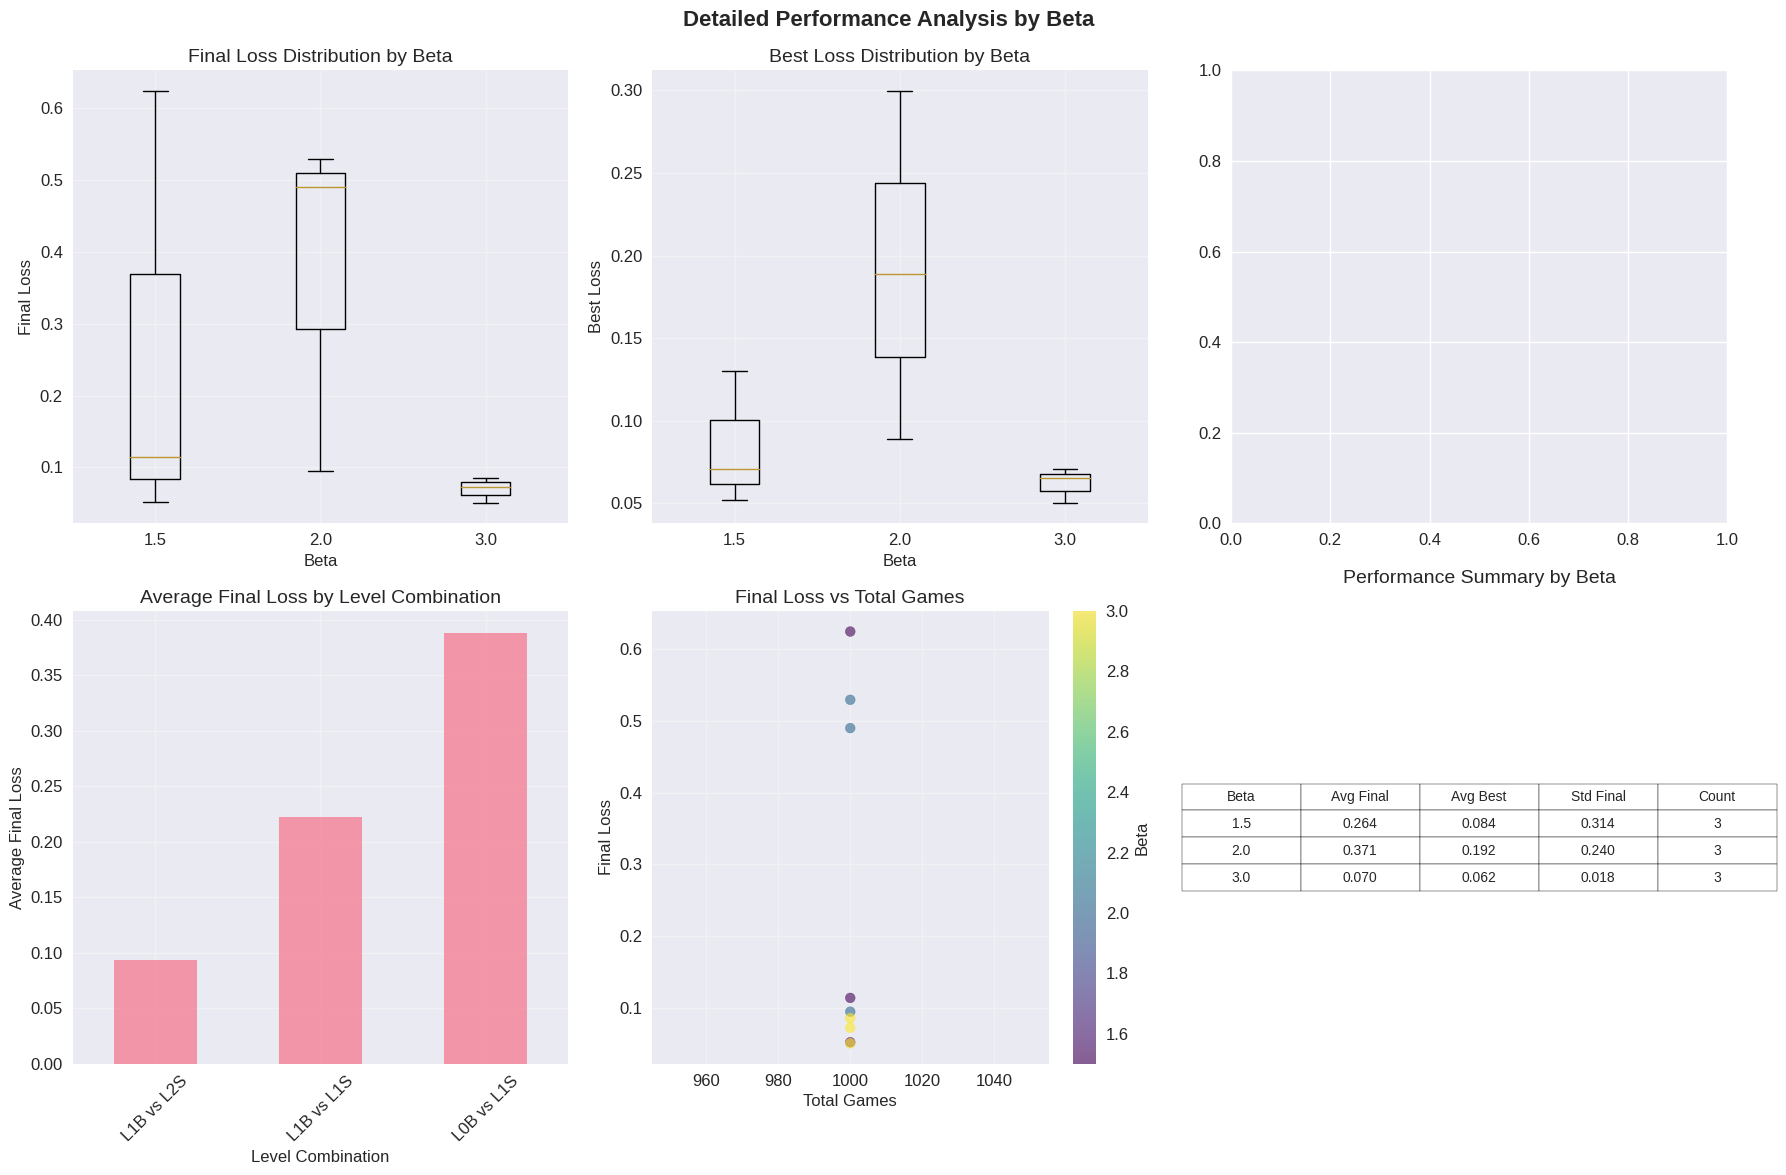

In [4]:
# 다중 실험 결과 비교를 위한 설정
results_base_dir = "./results/exp2/"
results_dir = f"{results_base_dir}/20250612_2129"  # 비교하고 싶은 실험 날짜 입력

def load_beta_results(results_dir):
    """
    beta별 실험 결과를 로드하고 정리하는 함수
    """
    all_results = []
    
    # results_dir 내의 모든 json 파일 찾기
    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    json_files.sort()
    
    for json_file in json_files:
        filename = os.path.basename(json_file)
        
        # 파일명에서 beta, buyer_level, seller_level 추출
        # 예: beta1.5_L0B_vs_L1S_learning.json
        if filename.startswith("beta") and filename.endswith("_learning.json"):
            parts = filename.replace("_learning.json", "").split("_")
            beta_str = parts[0].replace("beta", "")
            beta = float(beta_str)
            
            # level 정보 추출
            level_info = "_".join(parts[1:])  # L0B_vs_L1S
            
            try:
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # 결과 정보 추출
                result = {
                    'beta': beta,
                    'buyer_level': data['buyer_level'],
                    'seller_level': data['seller_level'],
                    'level_combination': f"L{data['buyer_level']}B vs L{data['seller_level']}S",
                    'true_preference': tuple(data['true_preference']),
                    'filename': filename
                }
                
                # final_loss와 best_loss 정보가 있는지 확인
                if 'final_loss' in data:
                    result['final_loss'] = data['final_loss']
                if 'best_loss' in data:
                    result['best_loss'] = data['best_loss']
                if 'converged' in data:
                    result['converged'] = data['converged']
                if 'convergence_iteration' in data:
                    result['convergence_iteration'] = data['convergence_iteration']
                
                # games가 있는 경우 마지막 게임의 loss 정보 추출
                if 'games' in data and len(data['games']) > 0:
                    last_game = data['games'][-1]
                    if 'current_loss' in last_game:
                        result['final_loss'] = last_game['current_loss']
                    
                    # 모든 게임에서 최소 loss 찾기
                    losses = [game.get('current_loss', float('inf')) for game in data['games']]
                    if losses:
                        result['best_loss'] = min(losses)
                        result['total_games'] = len(data['games'])
                
                all_results.append(result)
                
            except Exception as e:
                print(f"Error loading {json_file}: {e}")
    
    return pd.DataFrame(all_results)

def plot_beta_loss_comparison(df):
    """
    Beta별 loss 비교 시각화
    """
    if df.empty:
        print("데이터가 없습니다.")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Analysis of Seller\'s True Preference Inference Performance by Beta', fontsize=16, fontweight='bold')
    
    # 1. Final Loss vs Beta (by level combination)
    ax1 = axes[0, 0]
    if 'final_loss' in df.columns:
        for level_combo in df['level_combination'].unique():
            subset = df[df['level_combination'] == level_combo]
            ax1.plot(subset['beta'], subset['final_loss'], 
                    marker='o', label=level_combo, linewidth=2, markersize=6)
        ax1.set_xlabel('Beta')
        ax1.set_ylabel('Final Loss')
        ax1.set_title('Final Loss vs Beta (by Level Combination)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    
    # 2. Best Loss vs Beta (by level combination)
    ax2 = axes[0, 1]
    if 'best_loss' in df.columns:
        for level_combo in df['level_combination'].unique():
            subset = df[df['level_combination'] == level_combo]
            ax2.plot(subset['beta'], subset['best_loss'], 
                    marker='s', label=level_combo, linewidth=2, markersize=6)
        ax2.set_xlabel('Beta')
        ax2.set_ylabel('Best Loss')
        ax2.set_title('Best Loss vs Beta (by Level Combination)')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Loss Improvement (Final - Best) vs Beta
    ax3 = axes[1, 0]
    if 'final_loss' in df.columns and 'best_loss' in df.columns:
        df['loss_improvement'] = df['final_loss'] - df['best_loss']
        for level_combo in df['level_combination'].unique():
            subset = df[df['level_combination'] == level_combo]
            ax3.plot(subset['beta'], subset['loss_improvement'], 
                    marker='^', label=level_combo, linewidth=2, markersize=6)
        ax3.set_xlabel('Beta')
        ax3.set_ylabel('Loss Improvement (Final - Best)')
        ax3.set_title('Learning Improvement vs Beta')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. Heatmap of Best Loss
    ax4 = axes[1, 1]
    if 'final_loss' in df.columns:
        # pivot table 생성
        pivot_data = df.pivot_table(values='best_loss', 
                                   index='level_combination', 
                                   columns='beta', 
                                   aggfunc='mean')
        
        if not pivot_data.empty:
            sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                       ax=ax4, cbar_kws={'label': 'Best Loss'})
            ax4.set_title('Best Loss Heatmap (Level vs Beta)')
            ax4.set_xlabel('Beta')
            ax4.set_ylabel('Level Combination')
    
    plt.tight_layout()
    plt.show()

def plot_detailed_beta_analysis(df):
    """
    Beta별 상세 분석 시각화
    """
    if df.empty:
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Detailed Performance Analysis by Beta', fontsize=16, fontweight='bold')
    
    # 1. Box plot of Final Loss by Beta
    ax1 = axes[0, 0]
    if 'final_loss' in df.columns:
        beta_values = sorted(df['beta'].unique())
        final_losses_by_beta = [df[df['beta'] == beta]['final_loss'].values for beta in beta_values]
        ax1.boxplot(final_losses_by_beta, labels=[f'{beta}' for beta in beta_values])
        ax1.set_xlabel('Beta')
        ax1.set_ylabel('Final Loss')
        ax1.set_title('Final Loss Distribution by Beta')
        ax1.grid(True, alpha=0.3)
    
    # 2. Box plot of Best Loss by Beta
    ax2 = axes[0, 1]
    if 'best_loss' in df.columns:
        best_losses_by_beta = [df[df['beta'] == beta]['best_loss'].values for beta in beta_values]
        ax2.boxplot(best_losses_by_beta, labels=[f'{beta}' for beta in beta_values])
        ax2.set_xlabel('Beta')
        ax2.set_ylabel('Best Loss')
        ax2.set_title('Best Loss Distribution by Beta')
        ax2.grid(True, alpha=0.3)
    
    # 3. Convergence Rate by Beta
    ax3 = axes[0, 2]
    if 'converged' in df.columns:
        convergence_rates = []
        for beta in beta_values:
            subset = df[df['beta'] == beta]
            if len(subset) > 0:
                conv_rate = subset['converged'].sum() / len(subset)
                convergence_rates.append(conv_rate)
            else:
                convergence_rates.append(0)
        
        ax3.bar([f'{beta}' for beta in beta_values], convergence_rates, alpha=0.7)
        ax3.set_xlabel('Beta')
        ax3.set_ylabel('Convergence Rate')
        ax3.set_title('Convergence Rate by Beta')
        ax3.set_ylim(0, 1)
        ax3.grid(True, alpha=0.3)
    
    # 4. Average Final Loss by Level Combination
    ax4 = axes[1, 0]
    if 'final_loss' in df.columns:
        avg_loss_by_combo = df.groupby('level_combination')['final_loss'].mean().sort_values()
        avg_loss_by_combo.plot(kind='bar', ax=ax4, alpha=0.7)
        ax4.set_xlabel('Level Combination')
        ax4.set_ylabel('Average Final Loss')
        ax4.set_title('Average Final Loss by Level Combination')
        ax4.tick_params(axis='x', rotation=45)
        ax4.grid(True, alpha=0.3)
    
    # 5. Loss vs Games Count
    ax5 = axes[1, 1]
    if 'total_games' in df.columns and 'final_loss' in df.columns:
        ax5.scatter(df['total_games'], df['final_loss'], 
                   c=df['beta'], cmap='viridis', alpha=0.6, s=50)
        ax5.set_xlabel('Total Games')
        ax5.set_ylabel('Final Loss')
        ax5.set_title('Final Loss vs Total Games')
        cbar = plt.colorbar(ax5.collections[0], ax=ax5)
        cbar.set_label('Beta')
        ax5.grid(True, alpha=0.3)
    
    # 6. Beta효과 요약 테이블
    ax6 = axes[1, 2]
    if 'final_loss' in df.columns and 'best_loss' in df.columns:
        summary_stats = []
        for beta in sorted(df['beta'].unique()):
            subset = df[df['beta'] == beta]
            stats = {
                'Beta': beta,
                'Avg Final': f"{subset['final_loss'].mean():.3f}",
                'Avg Best': f"{subset['best_loss'].mean():.3f}",
                'Std Final': f"{subset['final_loss'].std():.3f}",
                'Count': len(subset)
            }
            summary_stats.append(stats)
        
        summary_df = pd.DataFrame(summary_stats)
        ax6.axis('tight')
        ax6.axis('off')
        table = ax6.table(cellText=summary_df.values, colLabels=summary_df.columns,
                         cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.5)
        ax6.set_title('Performance Summary by Beta', pad=20)
    
    plt.tight_layout()
    plt.show()

def analyze_beta_effects(df):
    """
    Beta 효과에 대한 통계 분석
    """
    if df.empty:
        print("분석할 데이터가 없습니다.")
        return
    
    print("=" * 60)
    print("Analysis of Seller's True Preference Inference Performance by Beta")
    print("=" * 60)
    
    # 기본 통계
    print(f"\nTotal number of experiments: {len(df)}")
    print(f"Beta range: {df['beta'].min():.1f} ~ {df['beta'].max():.1f}")
    print(f"Level combinations: {', '.join(df['level_combination'].unique())}")
    
    # Beta별 성능 요약
    if 'final_loss' in df.columns:
        print("\n[Analysis based on Final Loss]")
        beta_final_stats = df.groupby('beta')['final_loss'].agg(['mean', 'std', 'min', 'max', 'count'])
        print(beta_final_stats.round(4))
        
        # 최고/최악 성능 Beta
        best_beta = df.groupby('beta')['final_loss'].mean().idxmin()
        worst_beta = df.groupby('beta')['final_loss'].mean().idxmax()
        print(f"\nBest performing Beta: {best_beta} (Average Final Loss: {df[df['beta']==best_beta]['final_loss'].mean():.4f})")
        print(f"Worst performing Beta: {worst_beta} (Average Final Loss: {df[df['beta']==worst_beta]['final_loss'].mean():.4f})")
    
    if 'best_loss' in df.columns:
        print("\n[Analysis based on Best Loss]")
        beta_best_stats = df.groupby('beta')['best_loss'].agg(['mean', 'std', 'min', 'max'])
        print(beta_best_stats.round(4))
    
    # Level 조합별 분석
    if 'final_loss' in df.columns:
        print("\n[Performance by Level Combination]")
        level_stats = df.groupby('level_combination')['final_loss'].agg(['mean', 'std', 'count'])
        print(level_stats.round(4))
    
    # 수렴성 분석
    if 'converged' in df.columns:
        print("\n[Convergence Analysis]")
        conv_by_beta = df.groupby('beta')['converged'].agg(['sum', 'count', 'mean'])
        conv_by_beta.columns = ['Converged', 'Total', 'Rate']
        print(conv_by_beta.round(4))
        
def main():
    # 데이터 로드
    print("Loading experimental results by Beta...")
    df = load_beta_results(results_dir)
    
    if df.empty:
        print("No data loaded. Please check the file path and format.")
        return
    
    print(f"Loaded {len(df)} experimental results in total.")
    
    # 통계 분석
    analyze_beta_effects(df)
    
    # 시각화
    print("\nGenerating visualizations...")
    plot_beta_loss_comparison(df)
    plot_detailed_beta_analysis(df)
    
    return df

# 실행
df_results = main()